In [ ]:
!pip -q install scikit-learn==1.4.2 pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 134.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
cuml-cu12 26.2.0 requires scikit-learn>=1.5, but you have scikit-learn 1.4.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [ ]:
import os
import zipfile
from pathlib import Path

SRC_DIR = Path("/content")      # где лежат zip-файлы
DST_DIR = Path("/content/ieee") # куда распаковывать
DST_DIR.mkdir(parents=True, exist_ok=True)

# распаковываем все zip из /content
for zip_path in SRC_DIR.glob("*.zip"):
    print(f"Распаковываю: {zip_path.name}")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DST_DIR)

print("Готово. Файлы в:", DST_DIR)
print(os.listdir(DST_DIR))

Распаковываю: ieee-fraud-detection.zip
Распаковываю: train_transaction.csv.zip
Распаковываю: test_identity.csv.zip
Готово. Файлы в: /content/ieee
['test_transaction.csv', 'sample_submission.csv', 'train_transaction.csv', 'test_identity.csv', 'train_identity.csv']


In [ ]:
import os
import zipfile
from pathlib import Path

EXTRACT_DIR = "/content/ieee"
SRC_DIR = Path("/content")
DST_DIR = Path(EXTRACT_DIR)

DST_DIR.mkdir(parents=True, exist_ok=True)

print("Ищу zip-файлы в /content ...")
for zip_path in SRC_DIR.glob("*.zip"):
    if zipfile.is_zipfile(zip_path):
        print(f"Распаковываю: {zip_path.name}")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(DST_DIR)
    else:
        print(f"Пропускаю невалидный zip: {zip_path.name}")

print("\nЧто лежит в папке после распаковки:")
print(os.listdir(EXTRACT_DIR))

Ищу zip-файлы в /content ...
Распаковываю: ieee-fraud-detection.zip
Распаковываю: train_transaction.csv.zip
Распаковываю: test_identity.csv.zip

Что лежит в папке после распаковки:
['test_transaction.csv', 'sample_submission.csv', 'train_transaction.csv', 'test_identity.csv', 'train_identity.csv']


In [ ]:
RANDOM_STATE = 42
SAMPLE_FRAC = 0.2

MISSING_THR = 0.80
CONST_THR = 0.99

K_LIST = [0.01, 0.005]
USE_SCALER = False

In [ ]:
import pandas as pd
import gc
def read_csv_mem(path):
    df = pd.read_csv(path, low_memory=True)
    for c in df.columns:
        if df[c].dtype == "float64":
            df[c] = df[c].astype("float32")
        elif df[c].dtype == "int64":
            df[c] = df[c].astype("int32")
    return df

train_tr_path = f"{EXTRACT_DIR}/train_transaction.csv"
train_id_path = f"{EXTRACT_DIR}/train_identity.csv"

train_tr = read_csv_mem(train_tr_path)
train_id = read_csv_mem(train_id_path)

train = train_tr.merge(train_id, on="TransactionID", how="left")

del train_tr, train_id
gc.collect()

print("Train shape:", train.shape)
print("Fraud rate:", train["isFraud"].mean())

Train shape: (590540, 434)
Fraud rate: 0.03499000914417313


In [ ]:
if SAMPLE_FRAC < 1.0:
    train = train.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)

train = train.sort_values("TransactionDT").reset_index(drop=True)

n = len(train)
i1 = int(n * 0.70)
i2 = int(n * 0.85)

train_part = train.iloc[:i1].copy()
valid_part = train.iloc[i1:i2].copy()
test_part  = train.iloc[i2:].copy()

def split_stats(df, name):
    return {
        "split": name,
        "N": len(df),
        "Fraud_%": 100.0 * df["isFraud"].mean(),
        "AvgAmt": df["TransactionAmt"].mean()
    }

display(pd.DataFrame([
    split_stats(train_part, "train"),
    split_stats(valid_part, "valid"),
    split_stats(test_part,  "test"),
]))

,split,N,Fraud_%,AvgAmt
0,train,82675,3.592380,134.459686
1,valid,17716,3.589975,135.272141
2,test,17717,3.589773,136.705261


In [ ]:
TARGET = "isFraud"
ID_COL = "TransactionID"
TIME_COL = "TransactionDT"
AMT_COL = "TransactionAmt"

base_drop = {TARGET, ID_COL, TIME_COL}

feature_cols = [c for c in train.columns if c not in base_drop]

In [ ]:
def drop_high_missing(df, cols, thr):
    miss = df[cols].isna().mean()
    return miss[miss > thr].index.tolist()

def drop_quasi_constant(df, cols, thr):
    drops = []
    n = len(df)
    for c in cols:
        vc = df[c].value_counts(dropna=False)
        if len(vc) == 0:
            drops.append(c)
            continue
        top_ratio = float(vc.iloc[0]) / float(n)
        if top_ratio > thr:
            drops.append(c)
    return drops

drop_miss = drop_high_missing(train_part, feature_cols, MISSING_THR)
feature_cols_1 = [c for c in feature_cols if c not in set(drop_miss)]

drop_const = drop_quasi_constant(train_part, feature_cols_1, CONST_THR)
feature_cols_2 = [c for c in feature_cols_1 if c not in set(drop_const)]

print("Dropped missing>thr:", len(drop_miss))
print("Dropped quasi-constant>thr:", len(drop_const))
print("Final feature cols:", len(feature_cols_2))

feature_cols = feature_cols_2

Dropped missing>thr: 74
Dropped quasi-constant>thr: 15
Final feature cols: 342


In [ ]:
cat_cols = [c for c in feature_cols if train_part[c].dtype == "object"]
num_cols = [c for c in feature_cols if c not in cat_cols]

print("cat:", len(cat_cols), "num:", len(num_cols))

cat: 26 num: 316


In [ ]:
def fit_freq_maps(df, cat_cols):
    maps = {}
    n = len(df)
    for c in cat_cols:
        vc = df[c].astype("object").fillna("missing").value_counts(dropna=False)
        maps[c] = (vc / n).to_dict()
    return maps

freq_maps = fit_freq_maps(train_part, cat_cols)
medians = train_part[num_cols].median(numeric_only=True)

In [ ]:
def apply_freq_encoding_frame(X, cat_cols, maps):
    if not cat_cols:
        return X
    Xc = X[cat_cols].astype("object").fillna("missing")
    for c in cat_cols:
        Xc[c] = Xc[c].map(maps[c]).fillna(0.0).astype("float32")
    X[cat_cols] = Xc[cat_cols]
    return X

def build_matrix(df, labeled=True):
    X = df.reindex(columns=feature_cols).copy()

    X = apply_freq_encoding_frame(X, cat_cols, freq_maps)

    for c in num_cols:
        X[c + "_isna"] = X[c].isna().astype("int8")
        X[c] = pd.to_numeric(X[c], errors="coerce").fillna(medians.get(c, 0.0))

    X = X.astype("float32")

    if labeled:
        y = df[TARGET].astype(int).values
        amt = df[AMT_COL].values.astype("float64")
        return X, y, amt
    else:
        return X

X_train, y_train, amt_train = build_matrix(train_part, labeled=True)
X_valid, y_valid, amt_valid = build_matrix(valid_part, labeled=True)
X_test,  y_test,  amt_test  = build_matrix(test_part, labeled=True)

TRAIN_COLUMNS = X_train.columns.tolist()
X_valid = X_valid.reindex(columns=TRAIN_COLUMNS).fillna(0.0)
X_test  = X_test.reindex(columns=TRAIN_COLUMNS).fillna(0.0)

print(X_train.shape, X_valid.shape, X_test.shape)

/tmp/ipykernel_1072/3052885185.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[c + "_isna"] = X[c].isna().astype("int8")
/tmp/ipykernel_1072/3052885185.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[c + "_isna"] = X[c].isna().astype("int8")
/tmp/ipykernel_1072/3052885185.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented 

(82675, 658) (17716, 658) (17717, 658)


In [ ]:
def topk_pred(scores, k_frac):
    k = max(1, int(len(scores) * k_frac))
    idx = np.argsort(scores)[-k:]
    yhat = np.zeros(len(scores), dtype=int)
    yhat[idx] = 1
    return yhat

def best_f1_topk(y_true, scores, k_grid):
    best = {"k": None, "f1": -1.0}
    for k in k_grid:
        yhat = topk_pred(scores, k)
        f1 = f1_score(y_true, yhat, zero_division=0)
        if f1 > best["f1"]:
            best = {"k": float(k), "f1": float(f1)}
    return best

def eval_metrics(y_true, scores, k_for_f1):
    yhat = topk_pred(scores, k_for_f1)
    out = {
        "ROC_AUC": float(roc_auc_score(y_true, scores)),
        "PR_AUC(AP)": float(average_precision_score(y_true, scores)),
        "F1": float(f1_score(y_true, yhat, zero_division=0)),
        "k_for_F1": float(k_for_f1),
    }
    return out, yhat

def plot_roc_pr(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)

    p, r, _ = precision_recall_curve(y_true, scores)
    ap = average_precision_score(y_true, scores)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
    plt.plot([0,1], [0,1])
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(title + " ROC")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(r, p, label=f"AP={ap:.4f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(title + " PR")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    roc_auc_score, roc_curve,
    f1_score, confusion_matrix,
    ConfusionMatrixDisplay
)

BASE valid: {'ROC_AUC': 0.777855228079478, 'PR_AUC(AP)': 0.17626659067737713, 'F1': 0.24927295388450352, 'k_for_F1': 0.1}
BASE test : {'ROC_AUC': 0.7765379090894698, 'PR_AUC(AP)': 0.11512260013818046, 'F1': 0.22185292895720815, 'k_for_F1': 0.1}


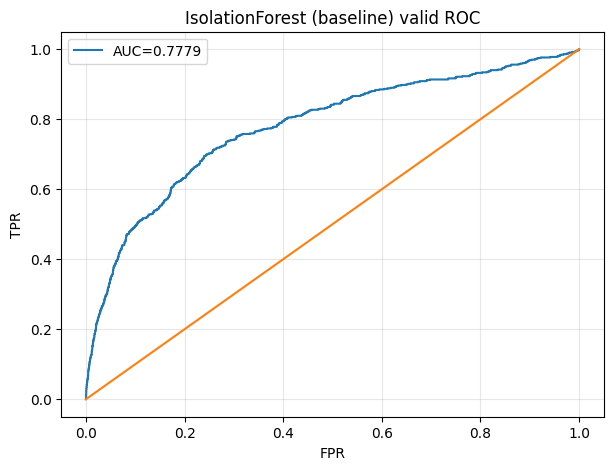

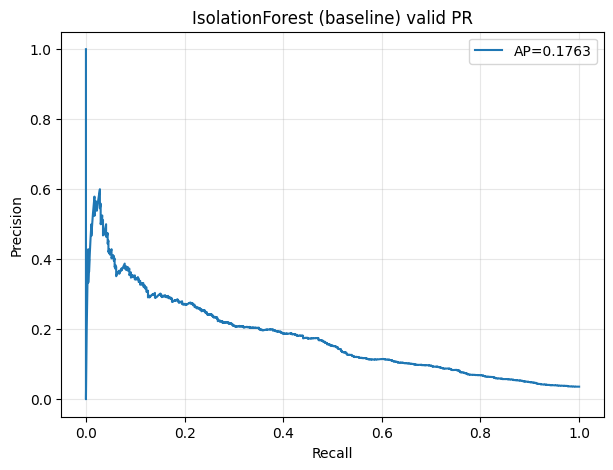

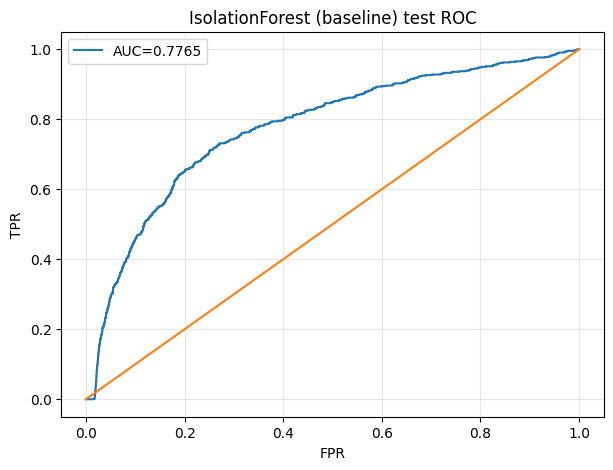

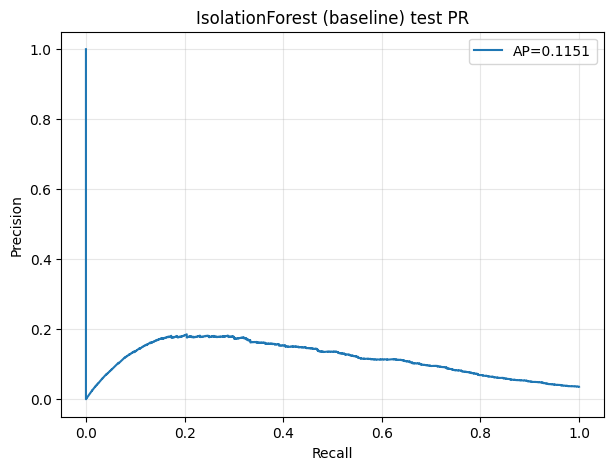

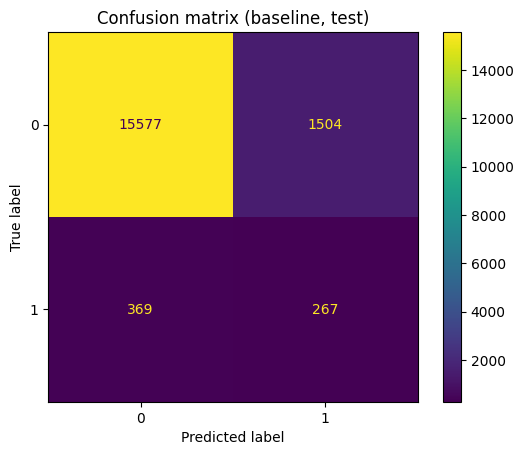

In [ ]:
def make_if_model(params, use_scaler=False):
    base = IsolationForest(**params)
    if use_scaler:
        return Pipeline([("scaler", StandardScaler()), ("if", base)])
    return base

def fit_if(model, X):
    model.fit(X)
    return model

def score_if(model, X):
    if isinstance(model, Pipeline):
        s = -model.named_steps["if"].decision_function(model.named_steps["scaler"].transform(X))
    else:
        s = -model.decision_function(X)
    return s.astype("float64")

baseline_params = dict(
    n_estimators=500,
    max_samples=256,
    max_features=0.7,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_model = make_if_model(baseline_params, use_scaler=USE_SCALER)
fit_if(baseline_model, X_train)

s_valid_base = score_if(baseline_model, X_valid)
s_test_base  = score_if(baseline_model, X_test)

k_grid = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
best_k_base = best_f1_topk(y_valid, s_valid_base, k_grid)["k"]

m_valid_base, yhat_valid_base = eval_metrics(y_valid, s_valid_base, best_k_base)
m_test_base,  yhat_test_base  = eval_metrics(y_test,  s_test_base,  best_k_base)

print("BASE valid:", m_valid_base)
print("BASE test :", m_test_base)

plot_roc_pr(y_valid, s_valid_base, "IsolationForest (baseline) valid")
plot_roc_pr(y_test,  s_test_base,  "IsolationForest (baseline) test")

cm = confusion_matrix(y_test, yhat_test_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion matrix (baseline, test)")
plt.show()

In [ ]:
param_grid = [
    {"n_estimators": 300, "max_samples": 256, "max_features": 0.5},
    {"n_estimators": 300, "max_samples": 256, "max_features": 0.7},
    {"n_estimators": 500, "max_samples": 256, "max_features": 0.5},
    {"n_estimators": 500, "max_samples": 256, "max_features": 0.7},
    {"n_estimators": 800, "max_samples": 256, "max_features": 0.7},
    {"n_estimators": 500, "max_samples": 0.2, "max_features": 0.7},
    {"n_estimators": 500, "max_samples": 0.5, "max_features": 0.7},
    {"n_estimators": 800, "max_samples": 0.2, "max_features": 0.7},
]

rows = []
for p in param_grid:
    params = dict(
        contamination="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **p
    )
    model = make_if_model(params, use_scaler=USE_SCALER)
    fit_if(model, X_train)
    s_valid = score_if(model, X_valid)

    best_k = best_f1_topk(y_valid, s_valid, k_grid)["k"]
    met, _ = eval_metrics(y_valid, s_valid, best_k)

    rows.append({
        **p,
        "valid_ROC_AUC": met["ROC_AUC"],
        "valid_PR_AUC": met["PR_AUC(AP)"],
        "valid_F1": met["F1"],
        "k_for_F1": met["k_for_F1"],
    })

tune_df = pd.DataFrame(rows).sort_values(["valid_PR_AUC", "valid_F1"], ascending=False)
display(tune_df)
best_params = tune_df.iloc[0].to_dict()
best_params

,n_estimators,max_samples,max_features,valid_ROC_AUC,valid_PR_AUC,valid_F1,k_for_F1
0,300,256.0,0.5,0.776646,0.177536,0.245891,0.05
3,500,256.0,0.7,0.777855,0.176267,0.249273,0.10
4,800,256.0,0.7,0.778264,0.176085,0.249273,0.10
2,500,256.0,0.5,0.775612,0.175416,0.255095,0.05
1,300,256.0,0.7,0.777496,0.171236,0.246780,0.10
7,800,0.2,0.7,0.748493,0.120978,0.190278,0.10
5,500,0.2,0.7,0.749650,0.120791,0.196926,0.10
6,500,0.5,0.7,0.746368,0.116486,0.181969,0.10


{'n_estimators': 300.0,
 'max_samples': 256.0,
 'max_features': 0.5,
 'valid_ROC_AUC': 0.776646294536992,
 'valid_PR_AUC': 0.17753571389003792,
 'valid_F1': 0.24589086127547666,
 'k_for_F1': 0.05}

BEST params: {'n_estimators': 300, 'max_samples': 256, 'max_features': 0.5, 'contamination': 'auto', 'random_state': 42, 'n_jobs': -1}
BEST valid : {'ROC_AUC': 0.776646294536992, 'PR_AUC(AP)': 0.17753571389003792, 'F1': 0.24589086127547666, 'k_for_F1': 0.05}
BEST test  : {'ROC_AUC': 0.7737258360921087, 'PR_AUC(AP)': 0.11384980742987444, 'F1': 0.2024983563445102, 'k_for_F1': 0.05}


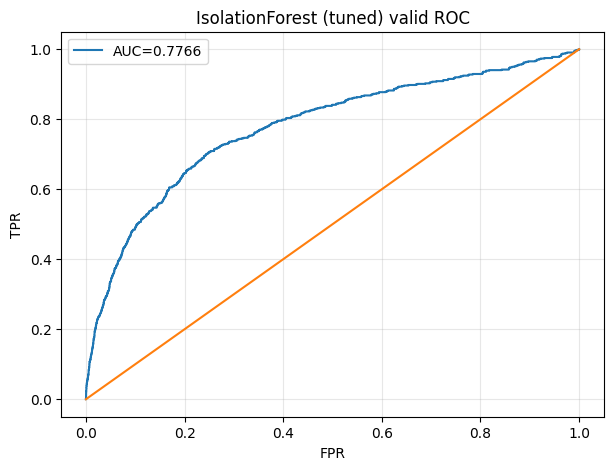

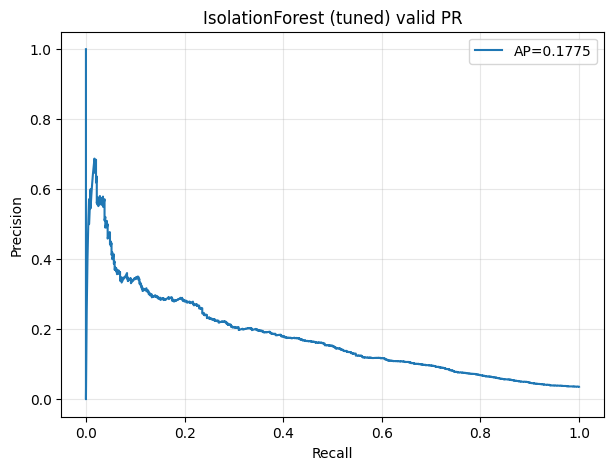

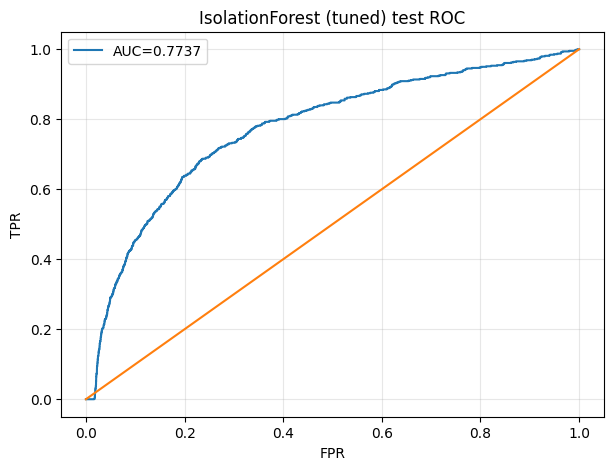

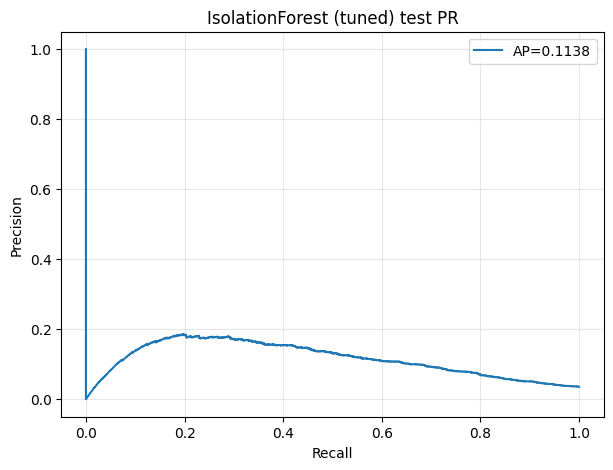

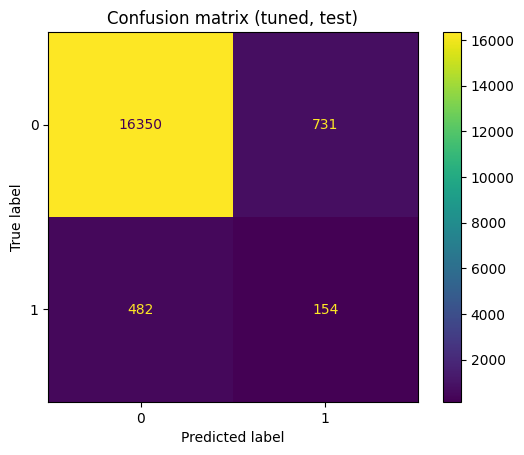

In [ ]:
ms = best_params["max_samples"]
ms = int(ms) if ms >= 1 else float(ms)

best_if_params = dict(
    n_estimators=int(best_params["n_estimators"]),
    max_samples=ms,
    max_features=float(best_params["max_features"]),
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_model = make_if_model(best_if_params, use_scaler=USE_SCALER)
fit_if(best_model, X_train)

s_valid_best = score_if(best_model, X_valid)
s_test_best  = score_if(best_model, X_test)

best_k = best_f1_topk(y_valid, s_valid_best, k_grid)["k"]

m_valid_best, yhat_valid_best = eval_metrics(y_valid, s_valid_best, best_k)
m_test_best,  yhat_test_best  = eval_metrics(y_test,  s_test_best,  best_k)

print("BEST params:", best_if_params)
print("BEST valid :", m_valid_best)
print("BEST test  :", m_test_best)

plot_roc_pr(y_valid, s_valid_best, "IsolationForest (tuned) valid")
plot_roc_pr(y_test,  s_test_best,  "IsolationForest (tuned) test")

cm = confusion_matrix(y_test, yhat_test_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion matrix (tuned, test)")
plt.show()

In [ ]:
summary = pd.DataFrame([
    {"Model": "IF_baseline", **m_valid_base, "Split": "valid"},
    {"Model": "IF_baseline", **m_test_base,  "Split": "test"},
    {"Model": "IF_tuned",    **m_valid_best, "Split": "valid"},
    {"Model": "IF_tuned",    **m_test_best,  "Split": "test"},
])

display(summary)

,Model,ROC_AUC,PR_AUC(AP),F1,k_for_F1,Split
0,IF_baseline,0.777855,0.176267,0.249273,0.10,valid
1,IF_baseline,0.776538,0.115123,0.221853,0.10,test
2,IF_tuned,0.776646,0.177536,0.245891,0.05,valid
3,IF_tuned,0.773726,0.113850,0.202498,0.05,test
